# 实验八之一：Kaggle Transformer 正弦波预测

本 Notebook 对应 `Transformer.pdf` 的 3.2 节：随机生成正弦波，用 Encoder-Decoder Transformer 根据前 80% 的序列预测后 20%。

课件要求与本实现的对应关系：

- 生成 1,000,000 个正弦波值并保存为 `data.npy`；
- 将连续信号切分为长度 100 的样本，再随机划分训练集和测试集；
- `src` 输入编码器，右移后的 `tgt` 输入解码器，`tgt_y` 作为监督标签；
- 模型包含输入映射、正余弦位置编码、2 层 8 头 Transformer 和输出层；
- 使用 MSE 与 Adam 训练 10 轮，分别评估 teacher forcing 和递归推理；
- 输出模型权重、评估指标和预测图。本实验按课件说明不生成 Kaggle 提交文件。

在 Kaggle 中直接 **Run All** 即使用课件完整参数。资源有限的本地机器可在启动 Jupyter 前设置 `LAB8_FAST_DEV_RUN=1` 做快速流程验证；快速结果不是正式实验结果。

In [1]:
import json
import math
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEFAULT_OUTPUT_DIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path.cwd()
OUTPUT_DIR = Path(os.environ.get("LAB8_OUTPUT_DIR", str(DEFAULT_OUTPUT_DIR))).expanduser().resolve()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Kaggle 默认不设置该变量，会使用课件的完整参数。
FAST_DEV_RUN = os.environ.get("LAB8_FAST_DEV_RUN", "0") == "1"
NUM_STEPS = 4_000 if FAST_DEV_RUN else 1_000_000
SEQUENCE_LENGTH = 40 if FAST_DEV_RUN else 100
BATCH_SIZE = 64 if FAST_DEV_RUN else 512
HIDDEN_DIM = 32 if FAST_DEV_RUN else 128
NUM_HEADS = 4 if FAST_DEV_RUN else 8
NUM_LAYERS = 1 if FAST_DEV_RUN else 2
NUM_EPOCHS = 2 if FAST_DEV_RUN else 10
LEARNING_RATE = 1e-3
SRC_RATIO = 0.75 if FAST_DEV_RUN else 0.8

print("PyTorch:", torch.__version__)
print("设备:", DEVICE)
print("输出目录:", OUTPUT_DIR)
print("快速冒烟测试:", FAST_DEV_RUN)

PyTorch: 2.2.2
设备: cpu
输出目录: /Users/bob.li/Code/DL-ZJU/lab8-1
快速冒烟测试: False


In [2]:
def train_test_split(array, test_size=0.2, random_state=None, shuffle=True):
    """本实验所需的轻量、可复现随机划分，避免额外依赖 scikit-learn。"""
    if not 0 < test_size < 1:
        raise ValueError("test_size 必须位于 (0, 1)")
    if len(array) < 2:
        raise ValueError("至少需要两个样本才能划分训练集与测试集")

    indices = np.arange(len(array))
    if shuffle:
        rng = np.random.default_rng(random_state)
        rng.shuffle(indices)
    test_count = min(len(array) - 1, max(1, int(round(len(array) * test_size))))
    test_indices = indices[:test_count]
    train_indices = indices[test_count:]
    return array[train_indices], array[test_indices]

## 1. 生成正弦波数据

课件采用采样间隔 0.1。这里用 `arange` 明确保证相邻横坐标之差恰为 0.1，并将数据保存为 `float32`，减少内存与磁盘占用。

In [3]:
def generate_data(data_path, num_steps, interval=0.1):
    x = np.arange(num_steps, dtype=np.float32) * np.float32(interval)
    y = np.sin(x).astype(np.float32)
    np.save(data_path, y)
    return x, y


DATA_PATH = OUTPUT_DIR / "data.npy"
x, y = generate_data(DATA_PATH, NUM_STEPS)

assert y.shape == (NUM_STEPS,)
assert y.dtype == np.float32
assert np.isfinite(y).all()
print("数据形状:", y.shape)
print("数值范围:", (float(y.min()), float(y.max())))
print("已保存:", DATA_PATH)

preview_count = min(1_000, NUM_STEPS)
plt.figure(figsize=(12, 3.5))
plt.plot(x[:preview_count], y[:preview_count], linewidth=1.2)
plt.title("Generated sine wave")
plt.xlabel("x")
plt.ylabel("sin(x)")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

数据形状: (1000000,)
数值范围: (-1.0, 1.0)
已保存: /Users/bob.li/Code/DL-ZJU/lab8-1/data.npy


<Figure size 1200x350 with 1 Axes>

## 2. 切分序列并构造数据集

对长度为 `L` 的每个样本，在 `N = int(L × ratio)` 处分割：

- `src = [x0, ..., x(N-1)]`；
- `tgt = [x(N-1), ..., x(L-2)]`，以 `src` 的最后一个值作为解码起点；
- `tgt_y = [xN, ..., x(L-1)]`，比 `tgt` 向后移动一步。

因此 `tgt` 与 `tgt_y` 长度相同，模型学习逐步预测下一个值。

In [4]:
def split_sequence(sequence, ratio=0.8):
    if sequence.ndim != 3:
        raise ValueError(f"输入应为 [batch, sequence_length, features]，实际为 {tuple(sequence.shape)}")
    src_end = int(sequence.shape[1] * ratio)
    if not 1 <= src_end < sequence.shape[1]:
        raise ValueError(f"ratio={ratio} 使分割点 {src_end} 无效")

    src = sequence[:, :src_end]
    tgt = sequence[:, src_end - 1 : -1]
    tgt_y = sequence[:, src_end:]
    return src, tgt, tgt_y


def load_and_partition_data(data_path, seq_length=100):
    data = np.load(data_path).astype(np.float32, copy=False)
    num_sequences = len(data) // seq_length
    if num_sequences == 0:
        raise ValueError("数据长度必须不小于 seq_length")

    usable_length = num_sequences * seq_length
    sequences = data[:usable_length].reshape(num_sequences, seq_length, 1)
    return sequences, 1


def make_datasets(sequences, test_size=0.2):
    train, test = train_test_split(
        sequences, test_size=test_size, random_state=SEED, shuffle=True
    )
    train_tensor = torch.from_numpy(np.ascontiguousarray(train))
    test_tensor = torch.from_numpy(np.ascontiguousarray(test))
    return TensorDataset(train_tensor), TensorDataset(test_tensor)


def visualize(src, target, pred_teacher, pred_infer, idx=0, save_path=None):
    src_np = src[idx, :, 0].detach().cpu().numpy()
    target_np = target[idx, :, 0].detach().cpu().numpy()
    teacher_np = pred_teacher[idx, :, 0].detach().cpu().numpy()
    infer_np = pred_infer[idx, :, 0].detach().cpu().numpy()

    src_len = len(src_np)
    src_x = np.arange(src_len)
    target_x = np.arange(src_len, src_len + len(target_np))

    fig, ax = plt.subplots(figsize=(12, 4.5))
    ax.plot(src_x, src_np, "bo-", markersize=3, linewidth=1.2, label="src")
    ax.plot(target_x, target_np, "go-", markersize=4, linewidth=1.5, label="target")
    ax.plot(target_x, teacher_np, "ro--", markersize=3, linewidth=1.2, label="teacher forcing")
    ax.plot(target_x, infer_np, "yo--", markersize=3, linewidth=1.2, label="autoregressive")
    ax.axvline(src_len - 0.5, color="gray", linestyle=":", linewidth=1)
    ax.set_title("Transformer sine-wave prediction")
    ax.set_xlabel("Time step")
    ax.set_ylabel("Signal value")
    ax.grid(alpha=0.2)
    ax.legend()
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=160, bbox_inches="tight")
    plt.show()
    return fig

In [5]:
# 用一个极小样本验证三段序列的索引关系，避免预测与标签错位。
probe = torch.arange(10, dtype=torch.float32).view(1, 10, 1)
probe_src, probe_tgt, probe_y = split_sequence(probe, ratio=0.8)
assert probe_src[:, :, 0].tolist() == [[0, 1, 2, 3, 4, 5, 6, 7]]
assert probe_tgt[:, :, 0].tolist() == [[7, 8]]
assert probe_y[:, :, 0].tolist() == [[8, 9]]
assert probe_tgt.shape == probe_y.shape
print("序列切分检查通过:", probe_src.shape, probe_tgt.shape, probe_y.shape)

序列切分检查通过: torch.Size([1, 8, 1]) torch.Size([1, 2, 1]) torch.Size([1, 2, 1])


## 3. 正余弦位置编码

Transformer 会并行处理 token，本身不知道先后顺序。位置编码把不同频率的正弦和余弦值加到每个时间步的特征中，使模型能够利用位置信息。

In [6]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5_000):
        super().__init__()
        if d_model % 2 != 0:
            raise ValueError("此实现要求 d_model 为偶数")
        self.dropout = nn.Dropout(dropout)

        position = torch.arange(max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float32)
            * (-math.log(10_000.0) / d_model)
        )
        pe = torch.zeros(1, max_len, d_model, dtype=torch.float32)
        pe[0, :, 0::2] = torch.sin(position * div_term)
        pe[0, :, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe)

    def forward(self, x):
        if x.size(1) > self.pe.size(1):
            raise ValueError(f"序列长度 {x.size(1)} 超过位置编码上限 {self.pe.size(1)}")
        return self.dropout(x + self.pe[:, : x.size(1)])

## 4. Encoder-Decoder Transformer

训练阶段使用真实的 `tgt`（teacher forcing）；推理阶段只从 `src` 最后一个值开始，把每一步预测追加回解码器输入，递归生成完整未来序列。解码器使用 causal mask，禁止当前位置看到未来 token。

In [7]:
class TransformerWithPE(nn.Module):
    def __init__(
        self, in_dim, out_dim, embed_dim, num_heads, num_layers, dropout=0.1
    ):
        super().__init__()
        if in_dim != out_dim:
            raise ValueError("本实验的递归推理要求 in_dim == out_dim")

        self.out_dim = out_dim
        self.encoder_embedding = nn.Linear(in_dim, embed_dim)
        self.decoder_embedding = nn.Linear(out_dim, embed_dim)
        self.positional_encoding = PositionalEncoding(embed_dim, dropout=dropout)
        self.transformer = nn.Transformer(
            d_model=embed_dim,
            nhead=num_heads,
            num_encoder_layers=num_layers,
            num_decoder_layers=num_layers,
            dim_feedforward=4 * embed_dim,
            dropout=dropout,
            batch_first=True,
        )
        self.output_layer = nn.Linear(embed_dim, out_dim)

    def forward(self, src, tgt):
        src_features = self.positional_encoding(self.encoder_embedding(src))
        tgt_features = self.positional_encoding(self.decoder_embedding(tgt))
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(tgt.size(1)).to(tgt.device)
        hidden = self.transformer(src_features, tgt_features, tgt_mask=tgt_mask)
        return self.output_layer(hidden)

    @torch.no_grad()
    def infer(self, src, tgt_len):
        generated = src[:, -1:, :]
        for _ in range(tgt_len):
            next_value = self.forward(src, generated)[:, -1:, :]
            generated = torch.cat((generated, next_value), dim=1)
        return generated[:, 1:]


shape_model = TransformerWithPE(1, 1, HIDDEN_DIM, NUM_HEADS, NUM_LAYERS).to(DEVICE)
shape_model.eval()
with torch.no_grad():
    shape_src = torch.zeros(2, 8, 1, device=DEVICE)
    shape_tgt = torch.zeros(2, 3, 1, device=DEVICE)
    assert shape_model(shape_src, shape_tgt).shape == (2, 3, 1)
    assert shape_model.infer(shape_src, 3).shape == (2, 3, 1)
del shape_model
print("模型前向传播与递归推理形状检查通过")

模型前向传播与递归推理形状检查通过


## 5. 准备训练

完整实验沿用课件超参数：batch size 512、隐藏维度 128、8 个注意力头、2 层 Encoder/Decoder、学习率 1e-3。

In [8]:
sequences, num_features = load_and_partition_data(DATA_PATH, SEQUENCE_LENGTH)
train_set, test_set = make_datasets(sequences)

loader_generator = torch.Generator().manual_seed(SEED)
train_loader = DataLoader(
    train_set,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=loader_generator,
    num_workers=0,
    pin_memory=DEVICE.type == "cuda",
)
test_loader = DataLoader(
    test_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=DEVICE.type == "cuda",
)

model = TransformerWithPE(
    num_features, num_features, HIDDEN_DIM, NUM_HEADS, NUM_LAYERS
).to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.MSELoss()

first_batch = next(iter(train_loader))[0]
first_src, first_tgt, first_y = split_sequence(first_batch, SRC_RATIO)
assert first_tgt.shape == first_y.shape

print("全部序列:", sequences.shape)
print("训练/测试样本数:", len(train_set), len(test_set))
print("src/tgt/tgt_y:", first_src.shape, first_tgt.shape, first_y.shape)
print("可训练参数:", f"{sum(p.numel() for p in model.parameters()):,}")

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

全部序列: (10000, 100, 1)
训练/测试样本数: 8000 2000
src/tgt/tgt_y: torch.Size([512, 80, 1]) torch.Size([512, 20, 1]) torch.Size([512, 20, 1])
可训练参数: 926,849


## 6. 训练

每个 batch 都先构造 `src/tgt/tgt_y`，前向传播后最小化预测序列与 `tgt_y` 的均方误差。梯度裁剪用于降低偶发梯度爆炸的风险。

In [9]:
train_history = []

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    loss_sum = 0.0
    sample_count = 0

    for (batch,) in train_loader:
        batch = batch.to(DEVICE, non_blocking=True)
        src, tgt, tgt_y = split_sequence(batch, SRC_RATIO)

        optimizer.zero_grad(set_to_none=True)
        pred = model(src, tgt)
        loss = criterion(pred, tgt_y)
        if not torch.isfinite(loss):
            raise FloatingPointError(f"第 {epoch} 轮出现非有限损失: {loss.item()}")
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        batch_size_now = batch.size(0)
        loss_sum += loss.item() * batch_size_now
        sample_count += batch_size_now

    epoch_loss = loss_sum / sample_count
    train_history.append(epoch_loss)
    print(f"Epoch [{epoch:02d}/{NUM_EPOCHS:02d}] | train MSE: {epoch_loss:.6f}")

Epoch [01/10] | train MSE: 1.545887
Epoch [02/10] | train MSE: 0.131543
Epoch [03/10] | train MSE: 0.027146
Epoch [04/10] | train MSE: 0.013253
Epoch [05/10] | train MSE: 0.009052
Epoch [06/10] | train MSE: 0.007009
Epoch [07/10] | train MSE: 0.005745
Epoch [08/10] | train MSE: 0.005701
Epoch [09/10] | train MSE: 0.016929
Epoch [10/10] | train MSE: 0.015096


## 7. 测试与递归预测

这里分别报告两种指标：

- `teacher_forcing_mse`：解码器每一步都能看到前一个真实值，衡量一步预测能力；
- `autoregressive_mse`：只给定 `src`，后续全部使用模型自己的预测，误差会逐步累积，更接近真实预测场景。

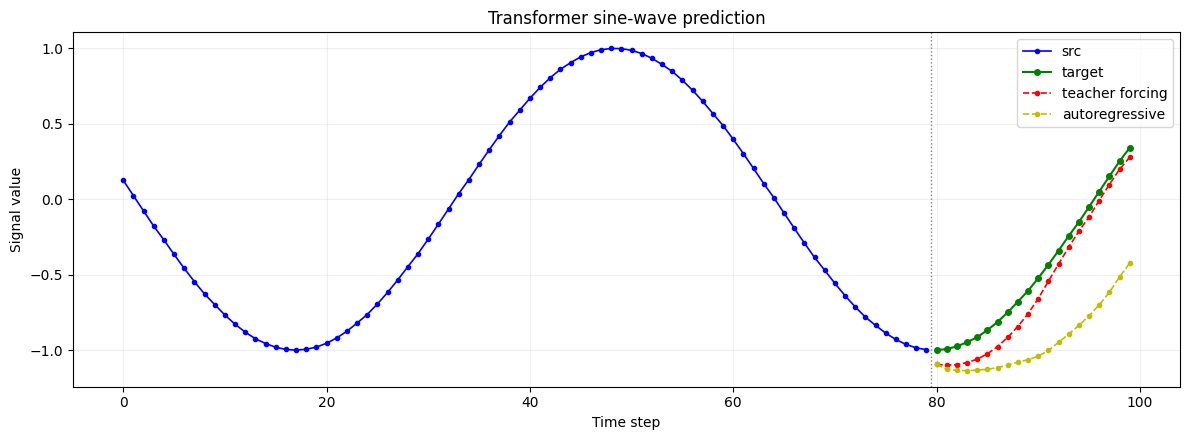

Teacher-forcing test MSE: 0.009087
Autoregressive test MSE:  0.188140
已保存模型: /Users/bob.li/Code/DL-ZJU/lab8-1/transformer_sine_model.pth
已保存指标: /Users/bob.li/Code/DL-ZJU/lab8-1/lab8_metrics.json
已保存预测图: /Users/bob.li/Code/DL-ZJU/lab8-1/lab8_sine_prediction.png


In [10]:
model.eval()
teacher_loss_sum = 0.0
infer_loss_sum = 0.0
sample_count = 0
example = None

with torch.no_grad():
    for batch_index, (batch,) in enumerate(test_loader):
        batch = batch.to(DEVICE, non_blocking=True)
        src, tgt, tgt_y = split_sequence(batch, SRC_RATIO)

        pred_teacher = model(src, tgt)
        pred_infer = model.infer(src, tgt_y.size(1))
        teacher_loss = criterion(pred_teacher, tgt_y)
        infer_loss = criterion(pred_infer, tgt_y)

        batch_size_now = batch.size(0)
        teacher_loss_sum += teacher_loss.item() * batch_size_now
        infer_loss_sum += infer_loss.item() * batch_size_now
        sample_count += batch_size_now

        if batch_index == 0:
            example = (src, tgt_y, pred_teacher, pred_infer)

teacher_forcing_mse = teacher_loss_sum / sample_count
autoregressive_mse = infer_loss_sum / sample_count
assert math.isfinite(teacher_forcing_mse)
assert math.isfinite(autoregressive_mse)

FIGURE_PATH = OUTPUT_DIR / "lab8_sine_prediction.png"
MODEL_PATH = OUTPUT_DIR / "transformer_sine_model.pth"
METRICS_PATH = OUTPUT_DIR / "lab8_metrics.json"

visualize(*example, save_path=FIGURE_PATH)

metrics = {
    "fast_dev_run": FAST_DEV_RUN,
    "teacher_forcing_mse": teacher_forcing_mse,
    "autoregressive_mse": autoregressive_mse,
    "train_mse_last_epoch": train_history[-1],
}
with open(METRICS_PATH, "w", encoding="utf-8") as file:
    json.dump(metrics, file, ensure_ascii=False, indent=2)

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "config": {
            "in_dim": num_features,
            "out_dim": num_features,
            "embed_dim": HIDDEN_DIM,
            "num_heads": NUM_HEADS,
            "num_layers": NUM_LAYERS,
            "sequence_length": SEQUENCE_LENGTH,
            "src_ratio": SRC_RATIO,
        },
        "metrics": metrics,
    },
    MODEL_PATH,
)

print(f"Teacher-forcing test MSE: {teacher_forcing_mse:.6f}")
print(f"Autoregressive test MSE:  {autoregressive_mse:.6f}")
print("已保存模型:", MODEL_PATH)
print("已保存指标:", METRICS_PATH)
print("已保存预测图:", FIGURE_PATH)

## 8. 结果解读

正常情况下，训练 MSE 会随 epoch 下降，teacher-forcing MSE 通常低于 autoregressive MSE。二者差距来自递归推理时的误差累积：模型前一步的轻微偏差会成为下一步输入。

提交实验报告时建议记录：完整参数是否运行、最后一轮训练 MSE、两种测试 MSE，以及 `lab8_sine_prediction.png` 中真实曲线与预测曲线的贴合情况。课件已明确本实验不需要提交 Kaggle 结果。